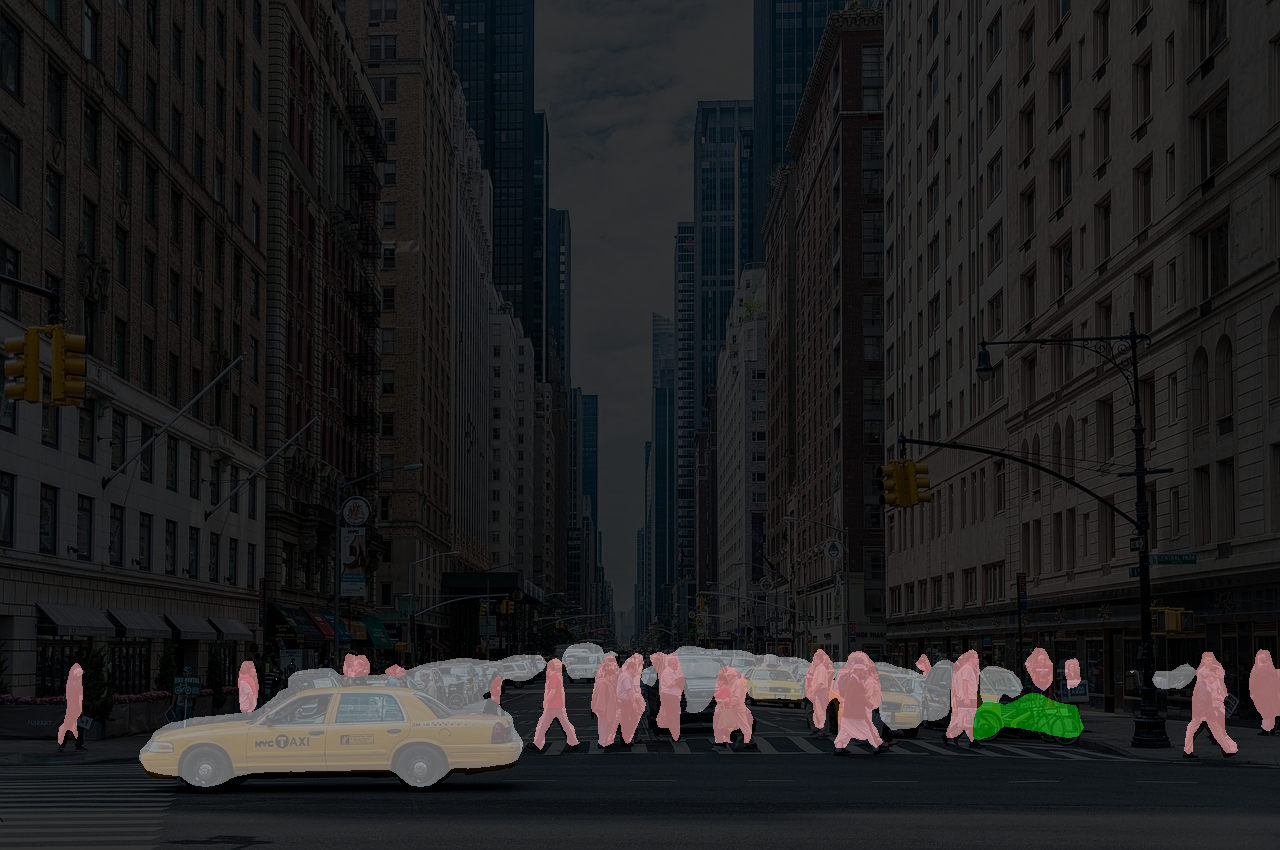

-1

In [8]:
import torchvision.transforms as transforms
import cv2
import numpy as np
import numpy
import torch
# from label_color_map import label_color_map as label_map

label_map = [
               (0, 0, 0),  # background
               (128, 0, 0), # aeroplane
               (0, 128, 0), # bicycle
               (128, 128, 0), # bird
               (0, 0, 128), # boat
               (128, 0, 128), # bottle
               (0, 128, 128), # bus
               (128, 128, 128), # car
               (64, 0, 0), # cat
               (192, 0, 0), # chair
               (64, 128, 0), # cow
               (192, 128, 0), # dining table
               (64, 0, 128), # dog
               (192, 0, 128), # horse
               (64, 128, 128), # motorbike
               (192, 128, 128), # person
               (0, 64, 0), # potted plant
               (128, 64, 0), # sheep
               (0, 192, 0), # sofa
               (128, 192, 0), # train
               (0, 64, 128) # tv/monitor
]

# First of all, the models are already trained on the COCO dataset.
# So, whatever images we give as input, we have to normalize them using
# mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].
## define the torchvision image transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def get_segment_labels(image, model, device):
    # transform the image to tensor and load into computation device
    image = transform(image).to(device)
    image = image.unsqueeze(0) # add a batch dimension
    outputs = model(image)
    # uncomment the following lines for more info
    # print(type(outputs))
    # print(outputs['out'].shape)
    # print(outputs)
    return outputs


def draw_segmentation_map(outputs):
    labels = torch.argmax(outputs.squeeze(), dim=0).detach().cpu().numpy()
    red_map = np.zeros_like(labels).astype(np.uint8)
    green_map = np.zeros_like(labels).astype(np.uint8)
    blue_map = np.zeros_like(labels).astype(np.uint8)

    for label_num in range(0, len(label_map)):
        index = labels == label_num
        red_map[index] = np.array(label_map)[label_num, 0]
        green_map[index] = np.array(label_map)[label_num, 1]
        blue_map[index] = np.array(label_map)[label_num, 2]

    segmented_image = np.stack([red_map, green_map, blue_map], axis=2)
    return segmented_image


def image_overlay(image, segmented_image):
    alpha = 0.8 # how much transparency to apply
    beta = 1 - alpha # alpha + beta should equal 1
    gamma = 0 # scalar added to each sum
    image = np.array(image)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)
    cv2.addWeighted(segmented_image, alpha, image, beta, gamma, image)
    return image

import torchvision
import numpy
import torch
# import segmentation_utils
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image



# download or load the model from disk
model = torchvision.models.segmentation.fcn_resnet50(pretrained=True)
# set computation device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model to eval() model and load onto computation devicce
model.eval().to(device)

# read the image
image = Image.open('/content/street2.jpg')
# do forward pass and get the output dictionary
outputs = get_segment_labels(image, model, device)
# get the data from the `out` key
outputs = outputs['out']
segmented_image = draw_segmentation_map(outputs)

final_image = image_overlay(image, segmented_image)
save_name = f"{'/content/street2.jpg'.split('/')[-1].split('.')[0]}"
# show the segmented image and save to disk
cv2_imshow( final_image)
cv2.waitKey(0)
# cv2.imwrite(f"outputs/{save_name}.jpg", final_image)